In [1]:
# The purpose of this notebook is that you need to join together all the files, 
# and then normalise them, and get them into a format that matches the format that Clara had for them 

In [1]:
import numpy as np
import xarray as xr    
import glob
import pandas as pd
import itertools
import sklearn

In [2]:
# Set the nemo_run
nemo_run = 'OPM0263'
this_collection = 'OPM0263_whole_dataset'

In [3]:
# Set all the filepaths that will be required 
filepath_data_ho = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/"
filepath_masks = filepath_data_ho + "masks_"
filepath_nico_on_nemo = filepath_data_ho + "nico_on_nemo_" + nemo_run + '.nc'
filepath_mask_nemo_run = filepath_masks + nemo_run + '.nc'
filepath_nn_input = filepath_data_ho + "nn_input_"
filepath_slopes = filepath_nn_input + nemo_run + '_' + 'redo_slopes2' + '.nc'
filepath_areas = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/areas.nc"

# Set where you would like to save the data 
data_out_fp = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
# Create a dataframe with all the data which is saved in this location
intermediate_filepath = data_out_fp + this_collection + '_' + 'not_yet_normalised.csv'
print(intermediate_filepath)

fp_metrics = data_out_fp + this_collection + '_' + 'metrics_norm.nc'
fp_var_train_norm = data_out_fp + this_collection + '_' + 'train_data.nc'
fp_var_val_norm = data_out_fp + this_collection + '_' + 'val_data.nc'

/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv


**Merge together the simulation datasets to create one dataset for the neural network training**

If you have already created a merged dataset, then you can skip this step

In [4]:
# Check which simulation datasets are available to look at 
processed_files = glob.glob(filepath_nn_input + nemo_run + '_1*.nc') + glob.glob(filepath_nn_input + nemo_run + '_2*.nc')
print('There are', len(processed_files), 'datasets available')

import os
years = []
months = []
for i in range(len(processed_files)):
#for i in range(10):
    path_sec = os.path.split(processed_files[i])[1].split('_')
    years.append(path_sec[3])
    months.append(path_sec[4].split('.')[0])
unique_years = np.unique(years)
unique_months = np.unique(months)
print('The available years are', unique_years)
print('The available months are', unique_months)
unique_years_int = np.ndarray(len(unique_years))
for i in range(len(unique_years)):
    unique_years_int[i] = int(unique_years[i])

There are 480 datasets available
The available years are ['1979' '1980' '1981' '1982' '1983' '1984' '1985' '1986' '1987' '1988'
 '1989' '1990' '1991' '1992' '1993' '1994' '1995' '1996' '1997' '1998'
 '1999' '2000' '2001' '2002' '2003' '2004' '2005' '2006' '2007' '2008'
 '2009' '2010' '2011' '2012' '2013' '2014' '2015' '2016' '2017' '2018']
The available months are ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12']


In [5]:
where_are_you_running = 'bettik'#, 'bettik', 'laptop'
# Set the filepaths for the data 
if where_are_you_running == 'bettik':
    filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
elif where_are_you_running == 'laptop':
    filepath_base = '/Users/ockendeh/Documents/simpleNN_basal_melt/'
else:
    print('Help: I don\'t know where to look for files')

# Set all the filepaths that will be required 
# For loading in the cavity geometry and creating the T/S profiles mask 
# Domain file from Christoph
filepath_cfg = filepath_base + 'AIAI_data/Christoph/domain_cfg_eANT025.L121_notime.nc'
# Or from Nico?
#filepath_cfg = '../MASKS_PARAM/domain_cfg_eANT025.L121.nc'
# Domain file for the reduced cavity geometry 
filepath_cfg_reduced_cav = filepath_base + 'MASKS_PARAM/domain_cfg_eANT025.L121_REDUCED_CAV.nc'
# Basin numbers 
filepath_basin_nos = filepath_base + 'MASKS_PARAM/basin_raster_extrapolate_eANT025.nc'

# For calculating the T/S profiles, you need the NEMO output data 
filepath_Christoph = filepath_base + 'AIAI_data/Christoph/'

# The output nc files include
if nemo_run == 'Christoph':
    # A geometry file with the masks of the different types of cell and the basins 
    filepath_mask = filepath_base +  'AIAI_data/Christoph/geometric_masks.nc'
    # A geometry file with the required variables for the NN 
    filepath_geomvars = filepath_base + 'AIAI_data/Christoph/geom_vars.nc'
elif nemo_run in ('OPM026','OPM031'):
    # The output nc files include
    # A geometry file with the masks of the different types of cell and the basins 
    filepath_mask = filepath_base +  'AIAI_data/Masks/OPM026_geometric_masks.nc'
    # A geometry file with the required variables for the NN 
    filepath_geomvars = filepath_base + 'AIAI_data/Masks/OPM026_geom_vars.nc'
elif nemo_run == 'OPM0263':
    # The output nc files include
    # A geometry file with the masks of the different types of cell and the basins 
    filepath_mask = filepath_base +  'AIAI_data/Masks/OPM0263_geometric_masks.nc'
    # A geometry file with the required variables for the NN 
    filepath_geomvars = filepath_base + 'AIAI_data/Masks/OPM0263_geom_vars.nc'


# The data files to be processed 
filepaths_so = glob.glob(filepath_Christoph + 'so-eANT025.L121-isf94-1m_*.nc')
filepaths_fwfisf = glob.glob(filepath_Christoph + 'fwfisf-eANT025.L121-isf94-1m_*.nc')
filepaths_thetao = glob.glob(filepath_Christoph + 'thetao-eANT025.L121-isf94-1m_*.nc')

# The output file path for the T,S, melt files 
filepaths_TSmelt = filepath_Christoph + 'TSmelt'

In [6]:
# Load in the closed_cavitites mask, and the slopes 
masks = xr.open_dataset(filepath_mask_nemo_run)
#closed_cavities = masks.closed_cavities.data
masks.close()
print('You have loaded:')
print(filepath_mask_nemo_run)
# Load in the slopes too 
#redone_slopes = xr.open_dataset(filepath_slopes)
#print(filepath_slopes)
#areas = xr.open_dataset(filepath_areas)
#print(filepath_areas)
# Load in the geometric fields too
masks = xr.open_dataset(filepath_mask)
print(filepath_mask)
geoms = xr.open_dataset(filepath_geomvars)
print(filepath_geomvars)

You have loaded:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/masks_OPM0263.nc
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM0263_geometric_masks.nc
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM0263_geom_vars.nc


In [7]:
# Load the pre-interpolated grids from file
#ds_load = xr.open_dataset(filepath_nico_on_nemo)
#print('You have loaded:')
#print(filepath_nico_on_nemo)
#dsREDCAV_NEMO = ds_load.dsREDCAV_NEMO.data
#basins_NEMO = ds_load.basins_NEMO.data
basins_NEMO = masks.basins_NEMO.data
#ds_load.close()
# Some ice shelves which should potentially be joined together into one bigger ice shelf
join_ice_shelves = True
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos_temp = np.unique(basins_NEMO)
count = np.zeros(len(basin_nos_temp))
for i in range(len(basin_nos_temp)):
    count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
mask_keep_nos = count != 0
basin_nos = basin_nos_temp[mask_keep_nos]

In [8]:
year = '2015'
month = '01'
verbose = 2
filepath_ij = filepath_nn_input + nemo_run + '_' + year + '_' + month + '.nc'
if verbose == 1:
    print('You have loaded:', filepath_ij)
data = xr.open_dataset(filepath_ij)
#print(data)#.temperature_prop

min_lat = -52.2
y_trim = np.max(np.argwhere(data.lat[:,0].data <= min_lat))
# Take this slice 
data = data.sel(y = slice(0,y_trim+1))
data = data.sel(x = slice(1,1441))

In [9]:
if data.dims['y'] > 439:
    min_lat = -52.2
    y_trim = np.max(np.argwhere(data.lat[:,0].data <= min_lat))
    # Take this slice 
    data = data.sel(y = slice(0,y_trim+1))
    data = data.sel(x = slice(1,1441))
mean_T = np.ones(basins_NEMO.shape)*np.nan
mean_S = np.ones(basins_NEMO.shape)*np.nan
std_T = np.ones(basins_NEMO.shape)*np.nan
std_S = np.ones(basins_NEMO.shape)*np.nan
for j in basin_nos:
    mask_basin = basins_NEMO*masks.closed_cavities_nan == j
    if np.sum(np.isnan(data.temperature_prop.data[mask_basin])) == 0:
        mean_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.temperature_prop.data[mask_basin])
        mean_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.salinity_prop.data[mask_basin])
        std_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.temperature_prop.data[mask_basin])
        std_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.salinity_prop.data[mask_basin])
    else:
        print(np.sum(np.isnan(data.temperature_prop.data[mask_basin])), 'nan cells in basin', j)
        mean_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.temperature_prop.data[mask_basin])
        mean_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.salinity_prop.data[mask_basin])
        std_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.temperature_prop.data[mask_basin])
        std_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.salinity_prop.data[mask_basin])
year_label = []
month_label = []
for i in range(len(std_S[masks.closed_cavities == 1])):
    year_label.append(year)
    month_label.append(month)

13 nan cells in basin 62.0


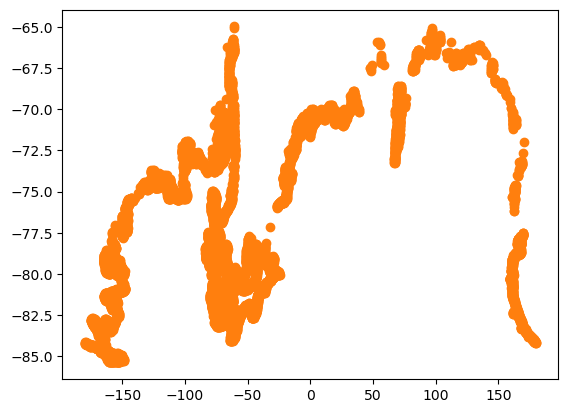

In [10]:
import matplotlib.pyplot as plt
plt.scatter(data.lon.data[np.isnan(mean_T)][masks.closed_cavities_nan.data[np.isnan(mean_T)]==1],
            data.lat.data[np.isnan(mean_T)][masks.closed_cavities_nan.data[np.isnan(mean_T)]==1], zorder = 10)
plt.scatter(data.lon.data[masks.closed_cavities == 1], data.lat.data[masks.closed_cavities == 1])

In [11]:
# Create a function to read in the simulation runs and convert them to pd dataframes
def create_df_total(nemo_run, year,month, verbose = 0):
    ''' This function reads in a .nc xarray file, and adds in the mean and std of T and S '''
    ''' and the slope parameters, and then saves these as a pandas dataframe to be merged '''
    filepath_ij = filepath_nn_input + nemo_run + '_' + year + '_' + month + '.nc'
    if verbose == 1:
        print('You have loaded:', filepath_ij)
    data = xr.open_dataset(filepath_ij)
    if data.dims['y'] > 439:
        min_lat = -52.2
        y_trim = np.max(np.argwhere(data.lat[:,0].data <= min_lat))
        # Take this slice 
        data = data.sel(y = slice(0,y_trim+1))
        data = data.sel(x = slice(1,1441))
    mean_T = np.ones(basins_NEMO.shape)*np.nan
    mean_S = np.ones(basins_NEMO.shape)*np.nan
    std_T = np.ones(basins_NEMO.shape)*np.nan
    std_S = np.ones(basins_NEMO.shape)*np.nan
    for j in basin_nos:
        mask_basin = basins_NEMO*masks.closed_cavities_nan == j
        if np.sum(np.isnan(data.temperature_prop.data[mask_basin])) == 0:
            mean_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.temperature_prop.data[mask_basin])
            mean_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.salinity_prop.data[mask_basin])
            std_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.temperature_prop.data[mask_basin])
            std_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.salinity_prop.data[mask_basin])
        else:
            #print(np.sum(np.isnan(data.temperature_prop.data[mask_basin])), 'nan cells in basin', j)
            mean_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.temperature_prop.data[mask_basin])
            mean_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanmean(data.salinity_prop.data[mask_basin])
            std_T[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.temperature_prop.data[mask_basin])
            std_S[mask_basin] = np.ones(len(data.temperature_prop.data[mask_basin])) * np.nanstd(data.salinity_prop.data[mask_basin])
    year_label = []
    month_label = []
    for i in range(len(std_S[masks.closed_cavities == 1])):
        year_label.append(year)
        month_label.append(month)
    df_total = pd.DataFrame({
                            'lat': data.lat.data[masks.closed_cavities == 1], 
                            'lon': data.lon.data[masks.closed_cavities == 1], 
                            'temperature_prop': data.temperature_prop.data[masks.closed_cavities == 1],
                            'salinity_prop': data.salinity_prop.data[masks.closed_cavities ==1],
                            'melt_m_ice_per_y': data.melt_ice_per_yr.data[masks.closed_cavities == 1],
                            'mean_T': mean_T[masks.closed_cavities == 1],
                            'mean_S': mean_S[masks.closed_cavities == 1],
                            'std_T': std_T[masks.closed_cavities == 1],
                            'std_S': std_S[masks.closed_cavities == 1], 
                            'year': year_label, 
                            'month': month_label, 
                            'basins_NEMO': basins_NEMO[masks.closed_cavities == 1],
                            'distances_GL': geoms.distances_GL.data[masks.closed_cavities == 1],
                            'distances_OO': geoms.distances_OO.data[masks.closed_cavities == 1],
                            'distances_OC': geoms.distances_OC.data[masks.closed_cavities == 1],
                            'corrected_isdraft': geoms.isf_draft.data[masks.closed_cavities ==1],
                            'area': geoms.areas.data[masks.closed_cavities == 1],
                            'bathymetry': geoms.bathymetry.data[masks.closed_cavities == 1],
                            'slope_is_lon': geoms.slope_isdraft_lon.data[masks.closed_cavities == 1],
                            'slope_is_lat': geoms.slope_isdraft_lat.data[masks.closed_cavities == 1],
                            'slope_ba_lon': geoms.slope_bathy_lon.data[masks.closed_cavities == 1],
                            'slope_ba_lat': geoms.slope_bathy_lat.data[masks.closed_cavities == 1],
                            'slope_is_across_front': geoms.slope_is_across_front.data[masks.closed_cavities == 1],
                            'slope_is_towards_front': geoms.slope_is_towards_front.data[masks.closed_cavities == 1],
                            'slope_ba_across_front': geoms.slope_ba_across_front.data[masks.closed_cavities == 1],
                            'slope_ba_towards_front': geoms.slope_ba_towards_front.data[masks.closed_cavities == 1],
                            })
    #print(np.sum(np.isnan(df_total['temperature_prop'])), 'nan values removed')
    df_total2 = df_total[~np.isnan(df_total['temperature_prop'])]
    return df_total2

In [12]:
intermediate_filepath

'/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv'

In [13]:
# Use the function create_df_total to create pandas dataframes for each simulation
# And then merge these together
# If you already have an merged but not normalised dataframe, then you can skip this step

merge = True
if merge == True:
    years_to_merge = unique_years_int
    months_to_merge = unique_months 
    for i,j in itertools.product(range(len(years_to_merge)), range(len(months_to_merge))):
        if i + j < 1:
            year = str(int(years_to_merge[0]))
            month = months_to_merge[0]
            df_total = create_df_total(nemo_run, year, month)
        else:
            year = str(int(years_to_merge[i]))
            month = months_to_merge[j]
            df_ij = create_df_total(nemo_run, year, month)
            df_total2 = pd.concat([df_total, df_ij], ignore_index=True)
            df_total = df_total2
        print((i * len(months_to_merge)) + j + 1, 'out of', (len(years_to_merge)* len(months_to_merge)), 'processed', end = '\r')   

    intermediate_save = True
    if intermediate_save == True:
        df_total.to_csv(intermediate_filepath, index = False)
        print('You have saved:        ')
        print(intermediate_filepath)

You have saved:        d
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv


### **Start here if you just want to create datasets for simulations**

You can start here if you've already merged together the simulations into a pandas dataframe (saved as intermediate_filepath)

**Separate out the testing data, and then split the rest into training and validation datasets**

In [ ]:
# Load in the merged dataframe 
df_total = pd.read_csv(intermediate_filepath)
df_all = df_total
print('You have loaded:')
print(intermediate_filepath)
print('There are', np.sum(np.sum(np.isnan(df_total), axis = 0), axis = 0), 'nan values in the dataset')
print('There are', df_total.shape[0], 'entries in the dataset')

In [ ]:
# Specify the years and months that you would like to keep 
# Specify which years and months you want in the dataframe for the training 
this_collection = 'no_middle_5'
if this_collection == 'whole_dataset':
    title = 'The entire dataset is used as training'
    months_mask = [1,2,3,4,5,6,7,8,9,10,11,12]
    years_mask = [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023]
elif this_collection == 'no_mar_oct':
    title = 'March and October are used for testing'
    months_mask = [1,2,4,5,6,7,8,10,11,12]
    years_mask = [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023]
elif this_collection == 'no_jun_dec':
    title = 'June and December are used for testing'
    months_mask = [1,2,3,4,5,7,8,9,10,11]
    years_mask = [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023]
elif this_collection == 'up_to_2018':
    title = 'Simulations after 2018 are used for testing'
    months_mask = [1,2,3,4,5,6,7,8,9,10,11,12]
    years_mask = [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018]
elif this_collection == 'after_1984':
    title = 'Simulations before 1984 are used for testing'
    months_mask = [1,2,3,4,5,6,7,8,9,10,11,12]
    years_mask = [1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023]
elif this_collection == 'no_middle_5':
    title = 'Simulations from 1999-2003 are used for testing'
    months_mask = [1,2,3,4,5,6,7,8,9,10,11,12]
    years_mask = [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023]
else:
    print('I do not know this collection, help!')
print('Creating the dataset with:')
print('Months:', months_mask)
print('Years:', years_mask)

In [ ]:
# Create a new data frame with the requested simulations
df_sel_month = df_all[np.isin(df_all.month, months_mask)]
df_sel_year = df_sel_month[np.isin(df_sel_month.year, years_mask)]
df_total = df_sel_year    

In [ ]:
annual_train = True
if annual_train == True:
    df_grouped = df_total.groupby(['lat','lon','year'], as_index = False).mean()
    df_total = df_grouped
    annual_f = 'annual_'
else:
    annual_f = ''

In [ ]:
plot_chosen_sims = False
if plot_chosen_sims == True:
    import matplotlib.pyplot as plt
    
    # Make a list of all the month/year combinations 
    year_and_months_t = np.unique(list(zip(df_all.year, df_all.month)), axis = 0)
    yr_t = year_and_months_t[:,0]
    mn_t = year_and_months_t[:,1]
    # Make a list of the requested months/years combination has been created 
    year_and_months = np.unique(list(zip(df_sel_year.year, df_sel_year.month)), axis = 0)
    yr_check = year_and_months[:,0]
    mn_check = year_and_months[:,1]
    # Create a mask for the month/years which have been left out
    mask = np.isin(year_and_months_t, year_and_months).all(axis = 1)
    # Create a random mask for the months/years which are used as validation
    a = np.zeros(yr_check.shape[0], dtype=int)
    a[:int(yr_check.shape[0]/10)] = 1
    np.random.shuffle(a)
    random_mask = a.astype(bool)

    # Plot this distribution of simulations
    fig, ax = plt.subplots(1,1, figsize = (8,2))
    plt.scatter(yr_check, mn_check, marker = "s", label = 'Training', color = 'C9')
    plt.scatter(yr_check[random_mask], mn_check[random_mask], marker = 's', color = 'C0', label = 'Validation')
    plt.scatter(yr_t[~mask], mn_t[~mask], marker = "s", color = 'C1', label = 'Testing', zorder = 0)
    ax.set_xticks((1980,1990,2000,2010,2020));
    ax.set_yticks((1,2,3,4,5,6,7,8,9,10,11,12));
    ax.set_yticklabels(('J','F','M','A','M','J','J','A','S','O','N','D'), fontsize = 8)
    ax.set_xlim(1978,2024)
    ax.set_ylim(0,13)
    ax.set_ylabel('Month', fontweight = 'bold')
    ax.set_xlabel('Year', fontweight = 'bold')
    ax.set_title(title, fontweight = 'bold');

In [ ]:
# Split the training and validation datasets 
fraction_for_validation = 1/9 # How much of the training/validation dataset to use for validation
                              # Assuming a 80:10:10 training:validation:testing split, set this to 1/9 
                              #    (as 1/10 for testing has already been taken)
                              # You can set this to False to use the whole dataset for training and validation
no_test = (df_all.shape[0] - df_total.shape[0])
if fraction_for_validation == False:
    train_input_df1 = df_total.copy()
    val_input_df1 = df_total.copy()
    no_train = df_total.shape[0]
    no_val = df_total.shape[0]
    print('Warning: You are not creating a separate validation dataset, this may affect the robustmess of your results')
else:
    # Split the data with the desired ratio (it is also shuffled)
    train_input_df1, val_input_df1 = \
            sklearn.model_selection.train_test_split(df_total, test_size = fraction_for_validation, random_state = 1)
    no_train = train_input_df1.shape[0]
    no_val = val_input_df1.shape[0]
print('Training data:   {} points, {:.0f}% of data'.format(no_train, no_train*100/df_all.shape[0]))
print('Validation data: {} points,  {:.0f}% of data'.format(no_val, no_val*100/df_all.shape[0]))
print('Testing data:    {} points,  {:.0f}% of data'.format(no_test, no_test*100/df_all.shape[0]))

train_input_df = train_input_df1.to_xarray()
val_input_df = val_input_df1.to_xarray()

## Prepare the training and validation datasets
y_train = train_input_df['melt_m_ice_per_y']
x_train = train_input_df.drop_vars(['melt_m_ice_per_y'])
y_val = val_input_df['melt_m_ice_per_y']
x_val = val_input_df.drop_vars(['melt_m_ice_per_y'])
print()
print('Training and validation datasets (x and y) prepared')

**If you want to, plot the training, validation and testing dataset distribution**

In [ ]:
plot_distribution_t_v = False
if plot_distribution_t_v == True:
    # Make a list of all the month/year combinations 
    year_and_months_t = np.unique(list(zip(df_all.year, df_all.month)), axis = 0)
    yr_t = year_and_months_t[:,0]
    mn_t = year_and_months_t[:,1]
    # Make a list of the requested months/years combination has been created 
    year_and_months = np.unique(list(zip(df_sel_year.year, df_sel_year.month)), axis = 0)
    yr_check = year_and_months[:,0]
    mn_check = year_and_months[:,1]
    # Create a mask for the month/years which have been left out
    mask = np.isin(year_and_months_t, year_and_months).all(axis = 1)
    # Create a random mask for the months/years which are used as validation
    a = np.zeros(yr_check.shape[0], dtype=int)
    a[:int(yr_check.shape[0]/10)] = 1
    np.random.shuffle(a)
    random_mask = a.astype(bool)
    print
    # Calculate the number of points in the training and validation datasets for each month/year
    len_trains = np.ndarray((len(months_mask), len(years_mask)))
    len_vals = np.ndarray((len(months_mask), len(years_mask)))
    for i, j in itertools.product(range(len(months_mask)), range(len(years_mask))):
        len_trains[i,j] = train_input_df1[np.isin(train_input_df1.year, years_mask[j]) & np.isin(train_input_df1.month, months_mask[i])].shape[0]
        len_vals[i,j] = val_input_df1[np.isin(val_input_df1.year, years_mask[j]) & np.isin(val_input_df1.month, months_mask[i])].shape[0]

# Define a function for plotting piechart markers 
def draw_pie(dist, xpos, ypos, size, ax=None):
    ''' Note this function came from stackoverflow, thank you Quang Hoang'''
    ''' https://stackoverflow.com/questions/56337732/how-to-plot-scatter-pie-chart-using-matplotlib '''
# for incremental pie slices
    cumsum = np.cumsum(dist)
    cumsum = cumsum/ cumsum[-1]
    pie = [0] + cumsum.tolist()
    for r1, r2 in zip(pie[:-1], pie[1:]):
        angles = np.linspace(2 * np.pi * r1, 2 * np.pi * r2, 100)
        x = [0] + np.cos(angles).tolist()
        y = [0] + np.sin(angles).tolist()
        xy = np.column_stack([x, y])
        # This function can actually deal with more than two slices, but you need to remove c = 'C0' if you want that functionality
        if r1 == 0:
            ax.scatter([xpos], [ypos], marker=xy, s=size, c = 'C9')
        else:
            ax.scatter([xpos], [ypos], marker=xy, s=size, c = 'C0')
    return ax

In [ ]:
if plot_distribution_t_v == True:
    import matplotlib.pyplot as plt
    # Plot the results 
    fig, ax = plt.subplots(1,2, figsize = (10,2), width_ratios = (8,2))
    ax[0].scatter(yr_check, mn_check, marker = "o", label = 'Training:    {:.0f}%'.format(no_train*100/df_all.shape[0]), color = 'C9')
    ax[0].scatter(yr_check[random_mask], mn_check[random_mask], marker = 'o', color = 'C0', \
                  label = 'Validation: {:.0f}%'.format(no_val*100/df_all.shape[0]))
    ax[0].scatter(yr_t[~mask], mn_t[~mask], marker = "o", color = 'C1', \
                  label = 'Testing:      {:.0f}%'.format(no_test*100/df_all.shape[0]), zorder = 0, s = 50)
    ax[0].set_xticks((1980,1990,2000,2010,2020));
    ax[0].set_yticks((1,2,3,4,5,6,7,8,9,10,11,12));
    ax[0].set_yticklabels(('J','F','M','A','M','J','J','A','S','O','N','D'), fontsize = 8)
    ax[0].set_xlim(1978,2024)
    ax[0].set_ylim(0,13)
    ax[0].set_ylabel('Month', fontweight = 'bold')
    ax[0].set_xlabel('Year', fontweight = 'bold')
    ax[0].set_title(title, fontweight = 'bold');
    for i, j in itertools.product(range(len(months_mask)), range(len(years_mask))):
        draw_pie([len_trains[i,j], len_vals[i,j]],years_mask[j],months_mask[i],50,ax=ax[0])
    ax[0].legend(loc = (1.4,0))
    
    ax[1].hist(np.ndarray.flatten(len_trains/(len_trains+len_vals))*100, bins = 20, color = 'C9');
    ax[1].set_xlabel('% Training data\n(for each month/year\nnot in testing data)', fontweight = 'bold')
    ax[1].set_ylabel('Frequency', fontweight = 'bold');

**Normalise the dataset**

In [ ]:
def compute_norm_metrics(x_train, y_train, norm_method):
    # Calculate the mean
    x_mean = x_train.mean()
    y_mean = y_train.mean()
    # Calulate the normalisation factor 
    if norm_method == 'std':
        x_range  = x_train.std()
        y_range  = y_train.std()
    elif norm_method == 'interquart':
        x_range  = x_train.quantile(0.9) - x_train.quantile(0.1)
        y_range  = y_train.quantile(0.9) - y_train.quantile(0.1)
    elif norm_method == 'minmax':
        x_range  = x_train.max() - x_train.min() 
        y_range  = y_train.max() - y_train.min() 
    # Merge methods 
    norm_mean = xr.merge([x_mean,y_mean]).assign_coords({'metric': 'mean_vars', 'norm_method': norm_method})
    norm_range = xr.merge([x_range,y_range]).assign_coords({'metric': 'range_vars', 'norm_method': norm_method})
    # Create array of metrics
    summary_metrics = xr.concat([norm_mean, norm_range], dim='metric').assign_coords({'norm_method': norm_method})
    return summary_metrics

In [ ]:
# Normalise the input and output data
norm_summary_list = []
for norm_method in ['std','interquart','minmax']:
    summary_ds = compute_norm_metrics(x_train, y_train, norm_method)
    norm_summary_list.append(summary_ds)
summary_ds_all = xr.concat(norm_summary_list, dim='norm_method')
print('Data normalised for all three methods')

# Calculate var mean, var 
var_mean = summary_ds_all.sel(metric='mean_vars')
var_range = summary_ds_all.sel(metric='range_vars')
var_train_norm = (train_input_df - var_mean)/var_range
var_val_norm = (val_input_df - var_mean)/var_range
print('Normalisation metrics calculated')

#set filenames
fp_metrics = data_out_fp + this_collection + '_' + annual_f + 'metrics_norm.nc'
fp_var_train_norm = data_out_fp + this_collection + '_' + annual_f + 'train_data.nc'
fp_var_val_norm = data_out_fp + this_collection + '_' + annual_f + 'val_data.nc'

# Set data to variables and save to file
metrics_ds, var_train_norm, var_val_norm = summary_ds_all, var_train_norm, var_val_norm
metrics_ds.to_netcdf(fp_metrics)
var_train_norm.to_netcdf(fp_var_train_norm)
var_val_norm.to_netcdf(fp_var_val_norm)    
print('You have saved:')
print(fp_metrics)
print(fp_var_train_norm)
print(fp_var_val_norm)